In [77]:
# utils
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

#sk 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

#plot
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 


### Basin probes visualization

In [78]:
save_figs = False 

In [79]:
base_cell_state_path = Path("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p")

In [80]:
with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_2m_temp_mean_basin_probe.p", "rb") as f: 
	temp_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_prec_basin_probe.p", "rb") as f: 
	prec_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_total_et_basin_probe.p", "rb") as f: 
	total_et_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_swe_basin_probe.p", "rb") as f: 
	swe_basin_probe_results = pickle.load(f)


In [85]:
results_list = [temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results]

### Magnitude and Activity

In [87]:
prec_basin_probe_results["1"]["model"].coef_

array([-0.01162185,  0.06310621, -0.        , -0.05767468, -0.        ,
       -0.        , -0.        ,  0.        ,  0.        ,  0.05975943,
       -0.11737535, -0.        ,  0.        ,  0.        ,  0.03976636,
        0.03251795,  0.        , -0.        , -0.        , -0.        ,
        0.        , -0.03093984, -0.23507833,  0.        , -1.0217836 ,
        0.        , -0.        ,  0.01018771, -0.        , -0.        ,
       -0.03728624, -0.        ,  0.        ,  0.        ,  0.011636  ,
        0.16342092,  0.        , -0.38209185, -0.        ,  0.06744202,
       -0.        , -0.        ,  0.        , -0.08089786, -0.11343521,
        0.        , -0.        , -0.        , -0.        ,  1.0488136 ,
       -0.        , -0.767786  , -0.8218415 ,  0.        , -0.        ,
       -0.        ,  0.        ,  0.        , -0.        ,  0.        ,
       -0.05009581, -0.        ,  0.31762874, -0.09515161, -0.        ,
       -0.        ,  0.0500929 ,  0.08033728, -0.        ,  0.  

In [83]:
var_name_list = ["temp", "prec", "total_et", "swe"]
var_name_list = ["prec"]

In [60]:
#load .shp and sort index 
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)


strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]

In [91]:
var_domain_magnitude_df = pd.DataFrame(0, columns=range(1,257,1), index=var_name_list, dtype=float)
var_domain_activity_df = pd.DataFrame(0, columns=range(1,257,1), index=var_name_list, dtype=float)
raw_m_list = []
raw_a_list = []


# try out std importance score 
for probe_results, name in zip(results_list[1],
							   var_name_list): 
	
	weights = [probe_results[b]["model"].coef_ for b in probe_results.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	raw_mag_df = pd.DataFrame(0, columns=weights_df.columns, index=weights_df.index, dtype=float)
	raw_act_df = pd.DataFrame(0, columns=weights_df.columns, index=weights_df.index, dtype=bool)

	# strata filter 
	#weights_df = weights_df.loc[strata_ids[strata_ids["0"] == 0].index, :]
	print(len(weights_df))

	# Std of weights over all basins. 
	sd = weights_df.std(axis=1)

	print(f"Relevant cells for representing {name}")

	m_list = []
	a_list = []

	for cell_state in weights_df:

		cell_state_col = weights_df.loc[:,cell_state]

		# mean weight over all basins
		basin_wise_magnitude = abs(cell_state_col / sd)
		raw_mag_df.loc[:, cell_state] = basin_wise_magnitude
		magnitude = basin_wise_magnitude.mean()
		m_list.append(magnitude)

		# determine percentage of basins where the cell is active
		activity = (cell_state_col !=0).sum() / len(cell_state_col) 
		raw_act_df.loc[:, cell_state] = (cell_state_col !=0)
		a_list.append(activity)

		p_flag = False

		if magnitude >= 2 or activity >= 0.5:
			pass
			#print(f"{cell_state+1}: mag = {magnitude} | act = {activity:.2f}")

	var_domain_magnitude_df.loc[name, :] = m_list
	var_domain_activity_df.loc[name, :] = a_list
	raw_m_list.append(raw_mag_df)
	raw_a_list.append(raw_act_df)


AttributeError: 'str' object has no attribute 'keys'

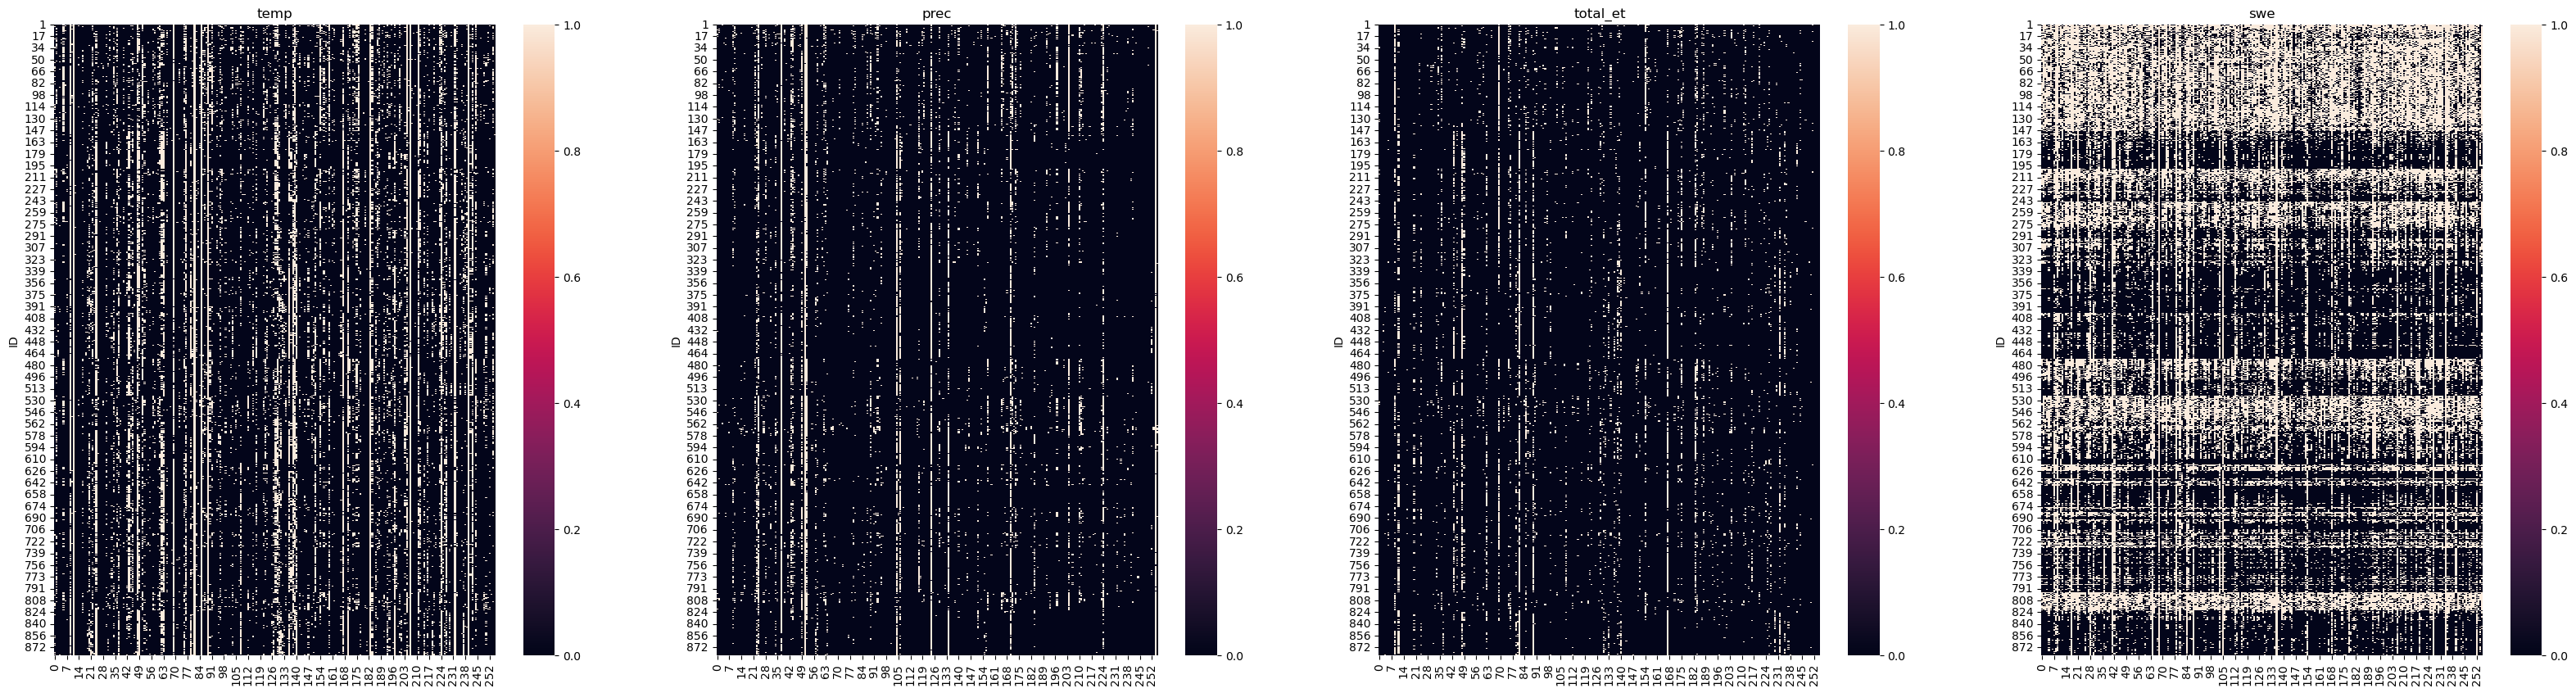

In [63]:
fig, axs = plt.subplots(1,4, figsize=(40,10))

for id, var in enumerate(var_name_list): 
    
	sns.heatmap(raw_a_list[id], ax=axs[id])
	axs[id].set_title(var)

In [65]:
var_domain_magnitude_df.loc["temp"].nlargest(5).index

Index([12, 82, 241, 184, 90], dtype='int64')

<Axes: >

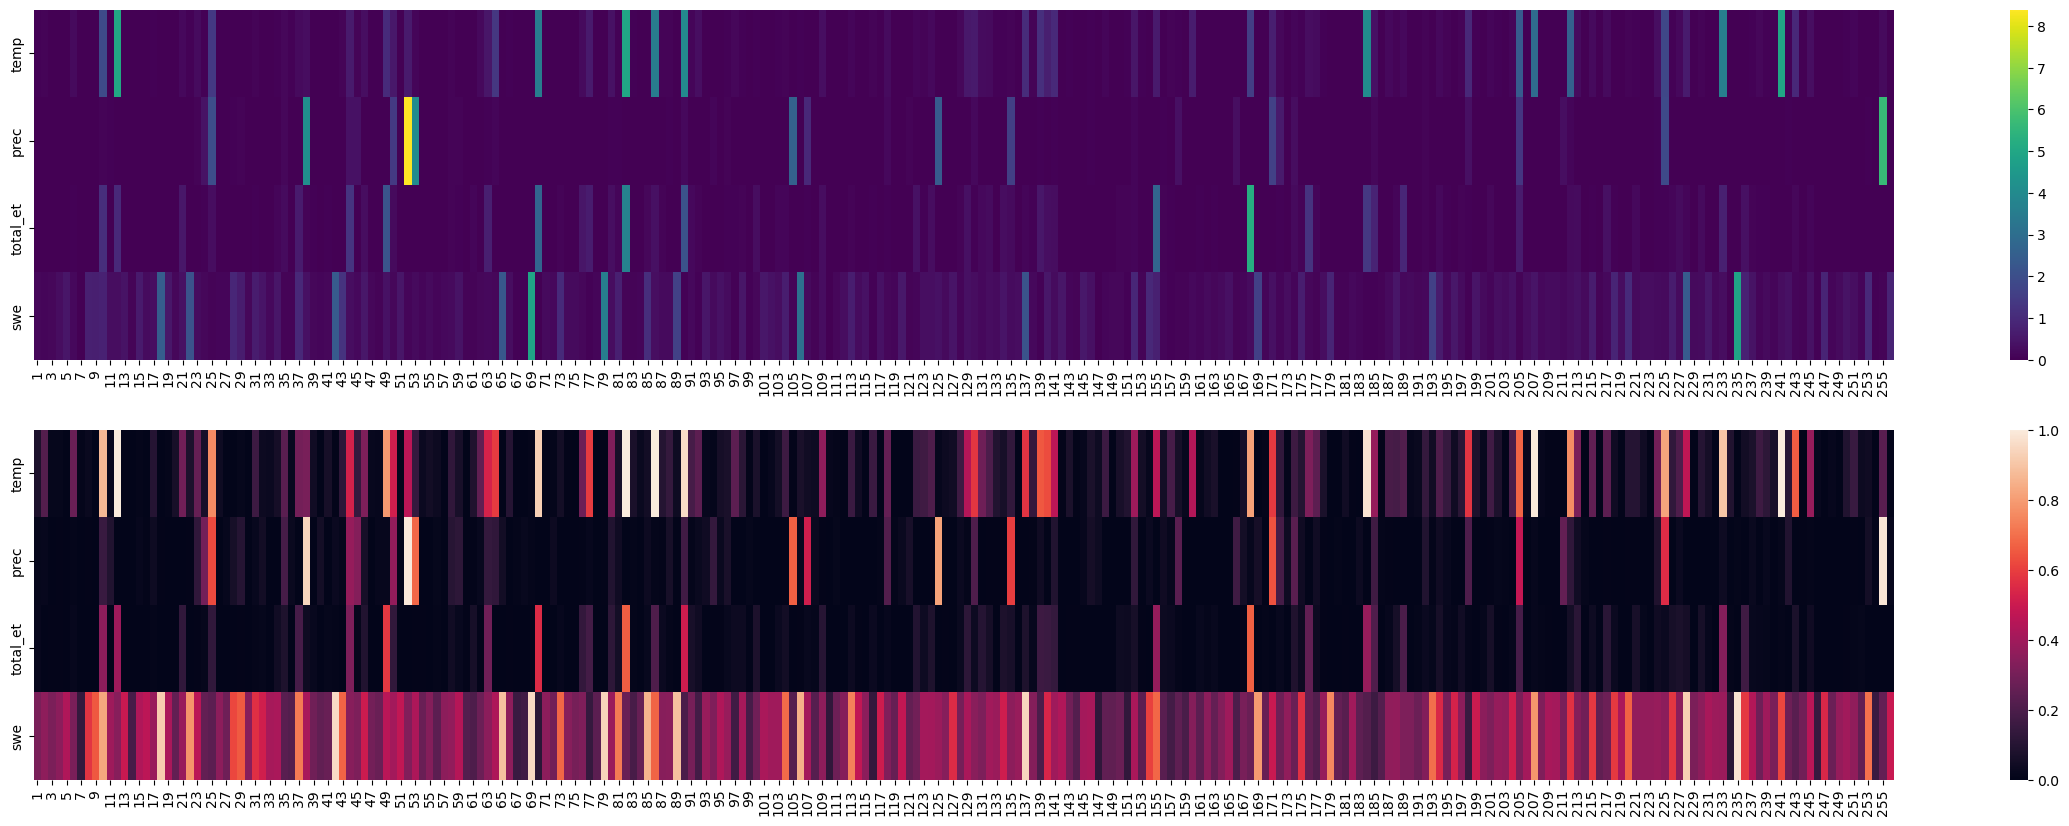

In [66]:
fig, axs = plt.subplots(2,1, figsize=(30,10))

sns.heatmap(var_domain_magnitude_df, ax=axs[0], cmap="viridis")
sns.heatmap(var_domain_activity_df, ax=axs[1])

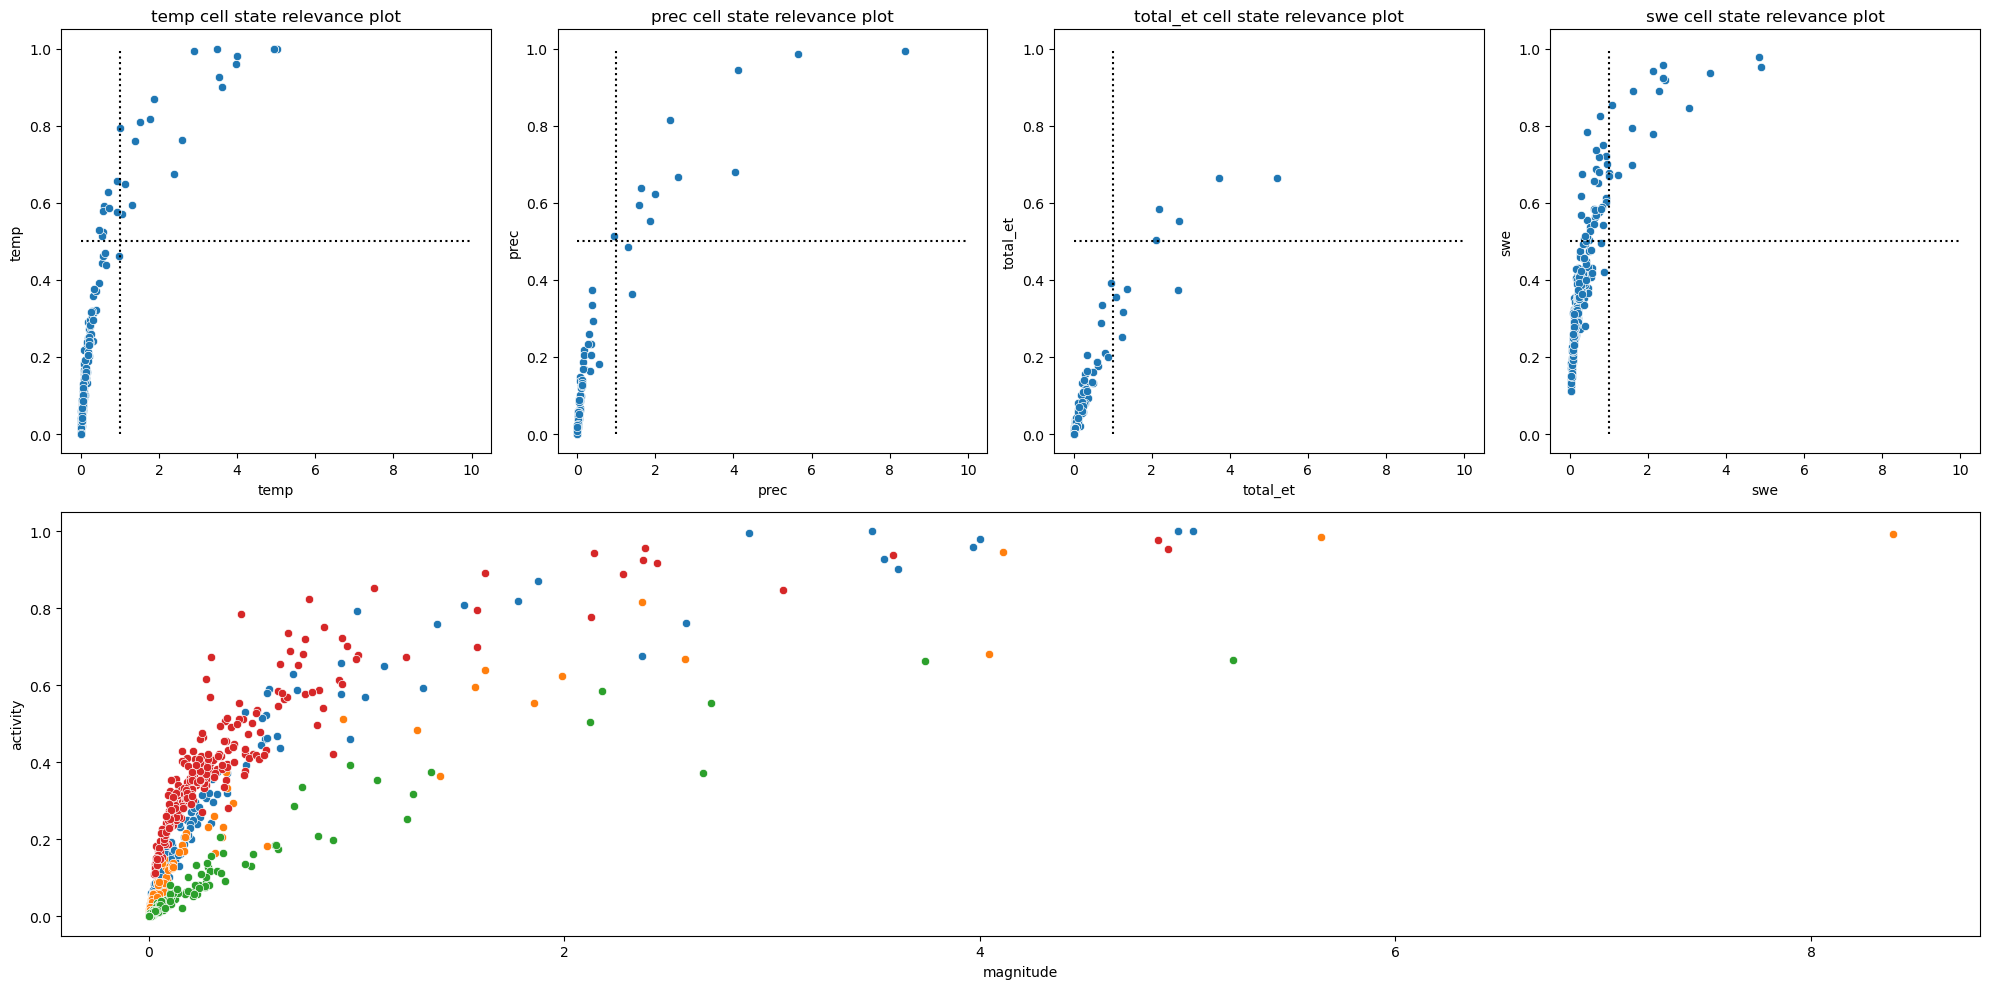

In [ ]:
fig, axs = plt.subplot_mosaic("ABCD;EEEE", figsize=(20,10))

for name, key in zip(var_name_list, list(axs.keys())[:-1]):

	# single plots
	sns.scatterplot(x=var_domain_magnitude_df.loc[name,:], y = var_domain_activity_df.loc[name,:], ax=axs[key],)
	plt.xlabel("magnitude")
	axs[key].vlines(x=1, ymin=0, ymax=1, linestyles=":", color="black")
	plt.ylabel("activity")
	axs[key].hlines(y=0.5, xmin=0, xmax=10, linestyles=":", color="black")

	axs[key].set_title(f"{name} cell state relevance plot")

	# combined plot
	sns.scatterplot(x=var_domain_magnitude_df.loc[name,:], y = var_domain_activity_df.loc[name,:], ax=axs["E"])
	plt.xlabel("magnitude")
	plt.ylabel("activity")
	axs[key].set_title(f"{name} cell state relevance plot")


plt.tight_layout()

### Cluster weights

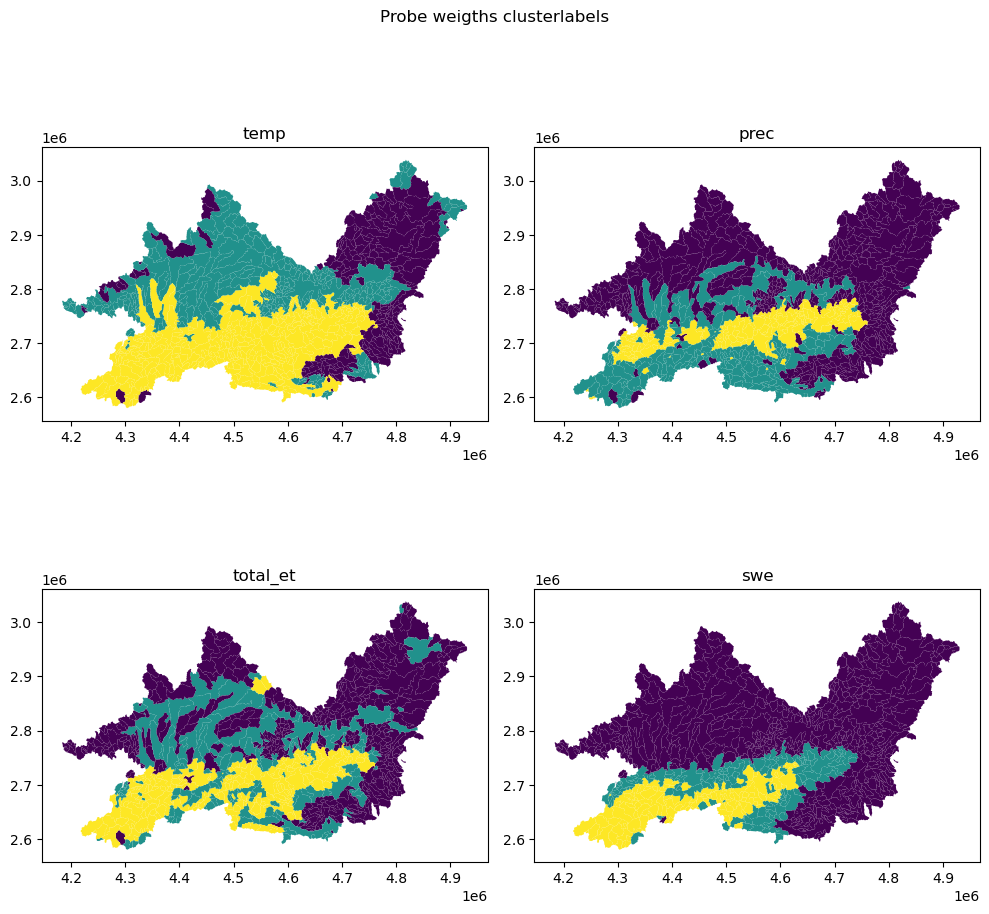

In [23]:
fig, axs = plt.subplots(2,2, figsize=(10,10))
fig.suptitle("Probe weigths clusterlabels")
kmeans = KMeans(3, random_state=134414)

for ax, probe, name in zip(
	axs.ravel(),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):

	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack)
	
	probe_weights_labels = kmeans.fit_predict(weights_df)	

	col = f"{name}_labels"
	lamah_gdf[col] = probe_weights_labels
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(f"{name}")

if save_figs:
	fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weigths_cluster.png", dpi=300)

plt.tight_layout()

### Old plots

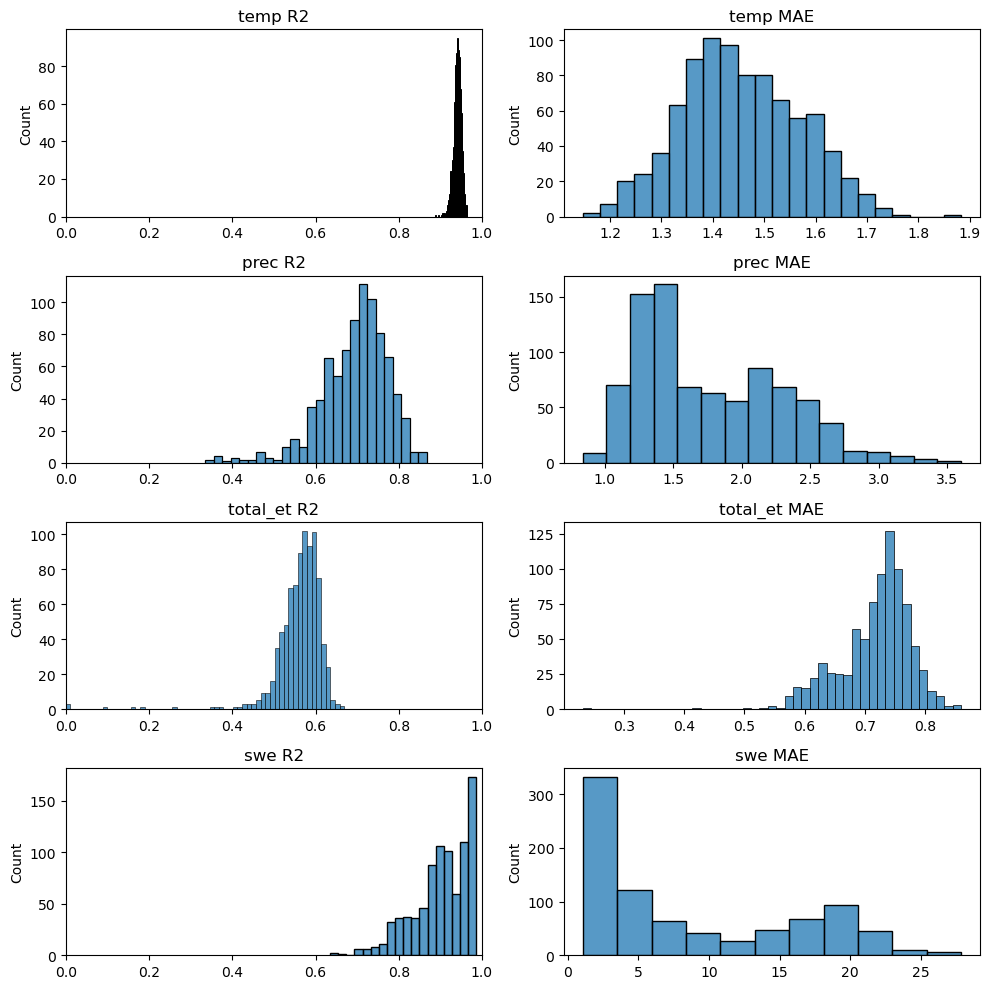

In [19]:
fig, axs = plt.subplots(4,2, figsize=(10,10))
axs = axs.ravel()

for i, probe, name in zip(
	list(range(0,8,2)),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):
	 
	basin_keys = list(probe.keys())[1:]

	basins_r2 = [probe[b]["R2"] for b in basin_keys]
	basins_mae = [probe[b]["MAE"] for b in basin_keys]

	sns.histplot(basins_r2, ax=axs[i])
	axs[i].set_title(f"{name} R2")
	axs[i].set_xlim(0,1)
	sns.histplot(basins_mae, ax=axs[i+1])
	axs[i+1].set_title(f"{name} MAE")

plt.tight_layout()

In [20]:
strata_labels = {
	0: "alpine",
	1: "plateau",
	2: "transition"
}

In [21]:
def relevance_check(cell_state_col: pd.Series, participation_threshold: float) -> bool: 

	if (cell_state_col !=0).sum() >= len(cell_state_col) * participation_threshold:  
		return True
	else:
		return False

KeyboardInterrupt: 

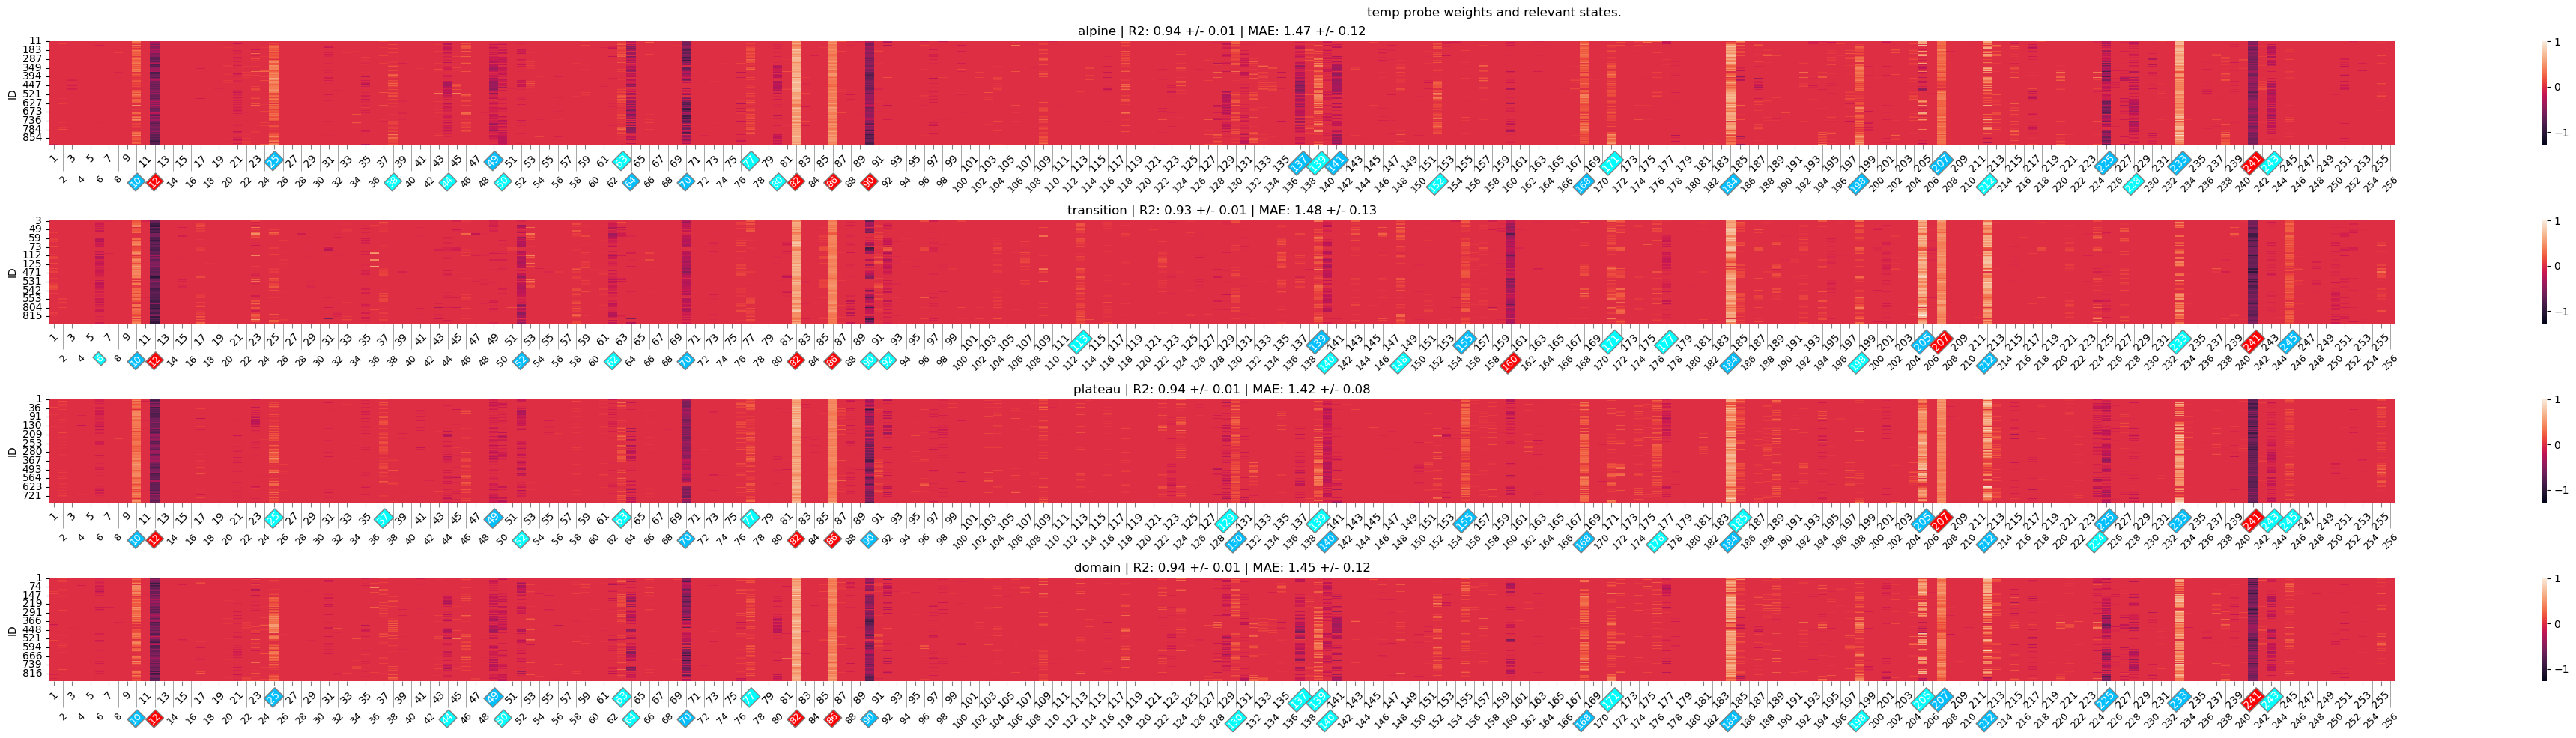

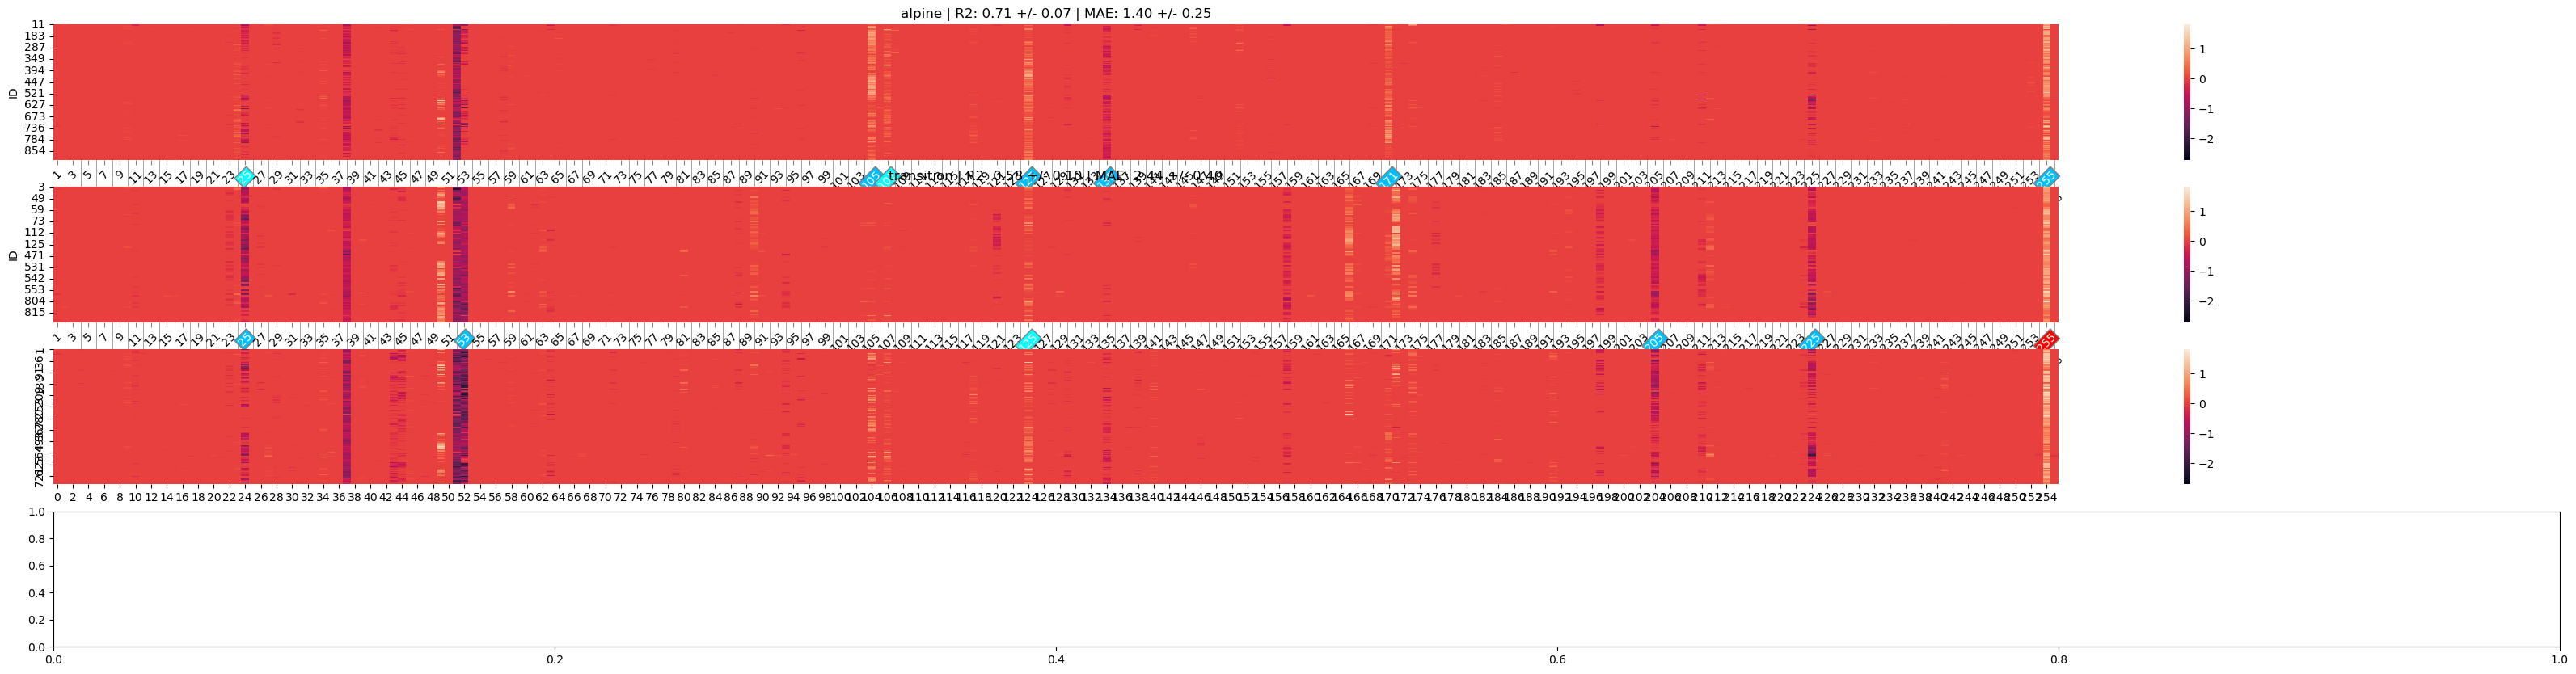

In [22]:
# dict to store state relevances
var_relevant_states = {}
var_name_list = ["temp", "prec", "total_et", "swe"]

for probe, name in zip([temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
                       var_name_list):
	
	#plot temp split between the three strata with the relevant states mark accordingly 
	relevance_level_colors = {
		0.5: "aqua",
		0.75: "deepskyblue",
		1.0 : "red"
	}

	#probe = prec_basin_probe_results

	rtwos_df = pd.DataFrame([probe[b]["R2"] for b in probe.keys()], index=strata_ids.index)
	maes_df = pd.DataFrame([probe[b]["MAE"] for b in probe.keys()], index=strata_ids.index)

	# stack weights and convert to df.
	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	fig, axs = plt.subplots(4,1, figsize=(40,10))

	strata_relevant_states_df = pd.DataFrame(columns=range(1,257))

	for id, ax in zip([0,2,1,3], axs.ravel()):

		# only filter ids in the stratas.
		selected_basin_ids = strata_ids[strata_ids["0"] == id].index if not id == 3 else strata_ids.index

		# Filter out all basins not in the current strata. 
		selected_basin_weights = weights_df.loc[selected_basin_ids, :]
		state_relevance_list = [0]*256

		selected_basins_mean_r2 = float(rtwos_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_r2 = float(rtwos_df.loc[selected_basin_ids,0].std())
		selected_basins_mean_mae = float(maes_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_mae = float(maes_df.loc[selected_basin_ids,0].std())
		
		for threshold in [0.5, 0.75, 1.0]: 
			
			counter = 0

			# Check for each column (weight) how often it ist larger than 0
			for col in selected_basin_weights.columns: 

				if relevance_check(selected_basin_weights.loc[:,col], threshold):
					state_relevance_list[col]=threshold
					counter += 1

			strata_name = strata_labels[id] if not id == 3 else "domain"

			#print(f"{name} in {strata_name} strata has {counter} cell states with >= {threshold*100}% participation.") 

		# after iteration of all threshold save final state relevances for strata to df
		strata_relevant_states_df.loc[strata_name,:] = np.array(state_relevance_list)

		sns.heatmap(selected_basin_weights, ax=ax, vmax=weights_df.max(axis=None), vmin=weights_df.min(axis=None))
		ax.set_title(f"{strata_name} | R2: {selected_basins_mean_r2:.2f} +/- {selected_basins_std_r2:.2f} | MAE: {selected_basins_mean_mae:.2f} +/- {selected_basins_std_mae:.2f}")
		
		# nest x-axis to allow for all state ids to be displayed without cluttering
		ticks_odd = np.arange(0.5, 256, 2)
		labels_odd = [str(i) for i in range(1, 257, 2)]
		
		ticks_even = np.arange(1.5, 256, 2)
		labels_even = [str(i) for i in range(2, 257, 2)]

		ax.set_xticks(ticks_odd)
		ax.set_xticklabels(labels_odd)
		ax.tick_params(axis='x', length=4, color="gray", labelrotation=45) 

		sec_ax = ax.secondary_xaxis('bottom')
		sec_ax.spines["bottom"].set_position(("outward", 25)) 
		sec_ax.set_xticks(ticks_even)
		sec_ax.set_xticklabels(labels_even, fontsize=9)	
		sec_ax.tick_params(axis='x', direction='in', length=40, width=0.5, color='gray', labelrotation=45) 
		sec_ax.spines["bottom"].set_color("none")

		all_axes = [(ax, ticks_odd, labels_odd), (sec_ax, ticks_even, labels_even)]
		
		for current_ax, ticks, labels in all_axes:
					
			tick_labels = current_ax.get_xticklabels()
			
			for text_obj in tick_labels:
				
					state_num = int(text_obj.get_text())
					
					# shift state_num (which is the state label (1-indexed)) by one to align with 0-indexed list of state_relevance_list
					state_relevance = state_relevance_list[state_num-1]
					
					if state_relevance in relevance_level_colors.keys():
						
						color = relevance_level_colors[state_relevance]

						# Bounding Box setzen
						text_obj.set_bbox(dict(
							facecolor=color, 
							edgecolor='gray', 
							boxstyle='square',
							pad=0.1 
						))
						if not color == "lightblue": 
							text_obj.set_color("white")
	
	var_relevant_states[name] = strata_relevant_states_df

	fig.suptitle(f"{name} probe weights and relevant states.")
	plt.tight_layout()

	if save_figs: 
		fig.savefig(f"/home/wuhlmann/BA/repo/lamah-ce_lstm/results/probing/{base_cell_state_path.stem}_{name}_probe_weights_and_important_states.png")


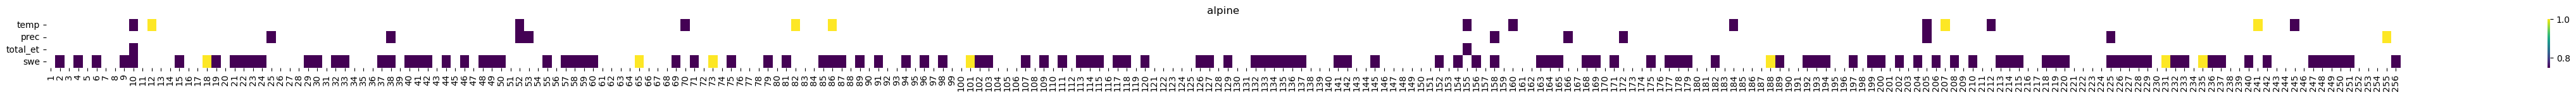

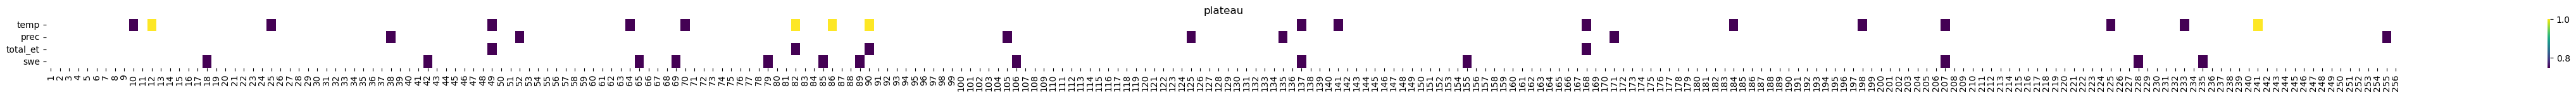

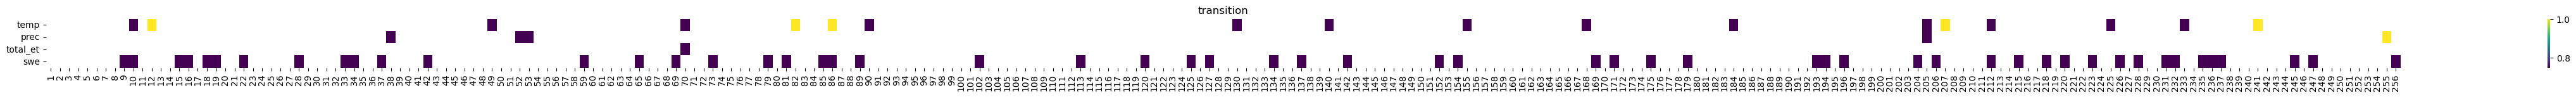

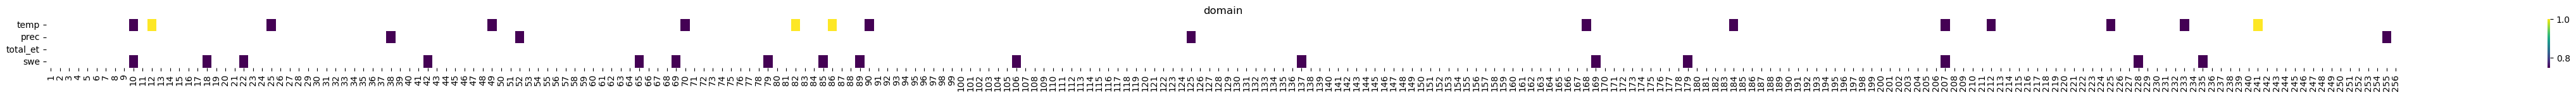

In [ ]:
for strata in list(strata_labels.values()) + ["domain"]:
	var_domain_relevance_df = pd.DataFrame(data=[var_relevant_states[var].loc[strata] for var in var_name_list], index=var_name_list)

	fig, ax = plt.subplots(1,1, figsize=(60,1))
	sns.heatmap(var_domain_relevance_df[var_domain_relevance_df > 0.5], cmap="viridis")
	ax.set_title(strata)